# Notebook 20 — NSV Stages 3 + 4 + Analysis  *(SIREN Refine, Dynamics MLP, Physical Interpretation)*
**Project:** ENSO-BSISO SSL — Neural State Variables extension  
**Author:** Jiayi (jh9141@nyu.edu)

Final notebook of the NSV pipeline. Consumes:
- `nb18c`'s 64-D Stage 1 latents (lp25, lag=10)
- `nb19`'s `intrinsic_dim.json` → **d̂ = 4** (from the patched-confidence run)

...and produces the **Neural State Variables** `v_t ∈ ℝ^{d̂=4}` plus their physical interpretation: which conventional climate variables does each `v` dimension correspond to?

## What this notebook does

**Stage 3 — SIREN refine autoencoder.** Compress the 64-D latent to d̂-dimensional state variables using a sinusoidal autoencoder (Sitzmann et al. 2020). The bottleneck `v_t = h_E(z_t) ∈ ℝ^{d̂}` is the Neural State Variable representation. Loss: `L = ‖h_D(h_E(z)) − z‖²`.

**Stage 4 — Dynamics MLP.** Train `f: v_t → v_{t+10}` (lag matches nb18c). Validates that the d̂-dim state space supports next-step prediction. If `f` works, the discovered state variables are genuinely dynamical.

**Analysis (the scientific payload).** For each of the d̂ Neural State Variables, compute Pearson correlation with conventional climate indices:
- BSISO amplitude (continuous)
- BSISO phase (categorical, via one-vs-rest)
- ENSO category (continuous EN=+1, Neutral=0, LN=−1)
- Calendar position within MJJAS (day-of-year)

Plus the **ENSO displacement z-score in v-space** — same procedure as nb05/nb09 — to compare with the project's earlier results.

## SIREN architecture (per Chen et al. + Sitzmann et al.)

```
Encoder h_E:  Linear(64 → 128) [sin] → Linear(128 → 64) [sin] → Linear(64 → 32) [sin] → Linear(32 → d̂)  [no activation]
Decoder h_D:  Linear(d̂ → 32) [sin] → Linear(32 → 64) [sin] → Linear(64 → 128) [sin] → Linear(128 → 64) [no activation]
```

SIREN activations: `sin(ω₀ · (Wx + b))` with `ω₀ = 30`. Critical: weight initialization is **NOT standard Kaiming** — Sitzmann's prescription is:
- First layer: `W ~ U(−1/n_in, 1/n_in)`
- Subsequent layers: `W ~ U(−√(6/n_in)/ω₀, +√(6/n_in)/ω₀)`

Wrong init makes SIREN networks fail to train.

## Dynamics MLP architecture

Standard ReLU MLP, identical to Chen et al.'s `LatentPredModel`:
```
v_t → Linear(d̂ → 32) [ReLU] → Linear(32 → 64) [ReLU] → Linear(64 → 64) [ReLU] → Linear(64 → 32) [ReLU] → Linear(32 → d̂)  [no activation]
```

## Inputs

- `nsv/latents_lag10/z_train.npy` shape `(3162, 64)`  ← nb18c output
- `nsv/latents_lag10/z_val.npy` shape `(837, 64)`
- `nsv/latents_lag10/{bsiso_phase_t, bsiso_amplitude_t, enso_cat_t, dates_t, train_mask}.npy`
- `nsv/results/stage2_lag10/intrinsic_dim.json` ← d̂ comes from here

## Outputs (`BSISO_SSL_Project/nsv/`)

- `checkpoints_lag10/refine_encoder.pth`, `refine_decoder.pth`, `dynamics_mlp.pth`
- `state_vars_lag10/v_train.npy` shape `(3162, d̂)`, `v_val.npy` shape `(837, d̂)`
- `results/stage3_4_lag10/refine_training.png`, `dynamics_training.png`, `v_scatter_phase_enso.png`, `dim_correlations.png`, `enso_displacement.png`, `stage3_4_summary.md`

## Decision rule

1. Stage 3 refine succeeds if val reconstruction MSE on z << variance of z (typical target: > 80% variance captured).
2. Stage 4 dynamics works if val MSE on v_{t+10} is meaningfully below the v-space persistence baseline.
3. Each of the d̂ dimensions should have at least one strong (|r| > 0.3) correlation with a physical index. If not, the dimension is a 'mystery axis' that warrants further investigation.

## Runtime

~5–8 min on Colab T4 (small models, 3,162 samples).

---

## Cell 1 — Setup: Load nb18c latents + nb19's d̂

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Variant switch (matches nb19's VARIANT). Default '_lag10' = nb18c outputs.
VARIANT = '_lag10'

PROJECT_DIR = '/content/drive/MyDrive/BSISO_SSL_Project'
NSV_DIR     = f'{PROJECT_DIR}/nsv'
LATENT_DIR  = f'{NSV_DIR}/latents{VARIANT}'
STAGE2_DIR  = f'{NSV_DIR}/results/stage2{VARIANT}'
CKPT_DIR    = f'{NSV_DIR}/checkpoints{VARIANT}'
STATE_DIR   = f'{NSV_DIR}/state_vars{VARIANT}'
RESULTS_DIR = f'{NSV_DIR}/results/stage3_4{VARIANT}'
for d in [CKPT_DIR, STATE_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:  {device}')
print(f'Variant: {VARIANT!r}')

# Load latents and labels
z_train     = np.load(f'{LATENT_DIR}/z_train.npy')
z_val       = np.load(f'{LATENT_DIR}/z_val.npy')
train_mask  = np.load(f'{LATENT_DIR}/train_mask.npy')
phase_t     = np.load(f'{LATENT_DIR}/bsiso_phase_t.npy')
amp_t       = np.load(f'{LATENT_DIR}/bsiso_amplitude_t.npy')
enso_t      = np.load(f'{LATENT_DIR}/enso_cat_t.npy')
dates_t     = np.load(f'{LATENT_DIR}/dates_t.npy')

# d_hat from nb19
with open(f'{STAGE2_DIR}/intrinsic_dim.json') as f:
    stage2 = json.load(f)
D_HAT = int(stage2['d_hat'])
Z_DIM = z_train.shape[1]
print(f'\nFrom nb19:  d̂ = {D_HAT}  (LB = {stage2["LB_mean"]:.2f} ± {stage2["LB_std"]:.2f}, Two-NN = {stage2["TwoNN"]:.2f}, lPCA = {stage2["lPCA"]:.2f})')
print(f'Stage 1 latent dim: {Z_DIM}.   SIREN bottleneck for nb20: {D_HAT}.')

# Aligned label vectors (train + val concatenated, same order as z_train ++ z_val)
order = np.concatenate([np.where(train_mask)[0], np.where(~train_mask)[0]])
phase_all = phase_t[order]
amp_all   = amp_t[order]
enso_all  = enso_t[order]
dates_all = dates_t[order]
z_all     = np.concatenate([z_train, z_val], axis=0)
is_train  = np.concatenate([np.ones(len(z_train), dtype=bool), np.zeros(len(z_val), dtype=bool)])

# ENSO as continuous: EN=+1, Neutral=0, LN=-1
enso_continuous_all = np.zeros(len(enso_all), dtype=np.float32)
enso_continuous_all[enso_all == 'El Nino'] = +1.0
enso_continuous_all[enso_all == 'La Nina'] = -1.0

# Day-of-year for seasonal-confound check
doy_all = pd.DatetimeIndex(dates_all).day_of_year.values.astype(np.float32)

print(f'\nAll arrays aligned. Total {len(z_all)} samples (train {is_train.sum()} / val {(~is_train).sum()}).')

Mounted at /content/drive
Device:  cpu
Variant: '_lag10'

From nb19:  d̂ = 4  (LB = 3.84 ± 0.00, Two-NN = 5.36, lPCA = 1.00)
Stage 1 latent dim: 64.   SIREN bottleneck for nb20: 4.

All arrays aligned. Total 3999 samples (train 3162 / val 837).


## Cell 2 — SIREN Autoencoder Architecture

Sinusoidal layer with Sitzmann initialization. The first layer uses a wider distribution because its input is unscaled; subsequent layers use the tighter `√(6/n_in)/ω₀` bound so the pre-activation distribution stays close to the input distribution of `sin`.

In [2]:
class SirenLayer(nn.Module):
    """Sinusoidal layer (Sitzmann et al. 2020) with proper weight initialization."""
    def __init__(self, in_features, out_features, omega_0=30.0, is_first=False):
        super().__init__()
        self.in_features = in_features
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                bound = 1.0 / self.in_features
            else:
                bound = math.sqrt(6.0 / self.in_features) / self.omega_0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-1e-3, 1e-3)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class SirenAutoencoder(nn.Module):
    """Refine model: 64 -> [128, 64, 32] -> d_hat -> [32, 64, 128] -> 64."""
    def __init__(self, z_dim=64, d_hat=4, omega_0=30.0):
        super().__init__()
        # Encoder
        self.e1 = SirenLayer(z_dim, 128, omega_0=omega_0, is_first=True)
        self.e2 = SirenLayer(128,  64,  omega_0=omega_0)
        self.e3 = SirenLayer(64,   32,  omega_0=omega_0)
        self.e4 = nn.Linear(32, d_hat)            # bottleneck — linear, no sin
        # Decoder
        self.d1 = SirenLayer(d_hat, 32, omega_0=omega_0, is_first=True)
        self.d2 = SirenLayer(32,    64, omega_0=omega_0)
        self.d3 = SirenLayer(64,   128, omega_0=omega_0)
        self.d4 = nn.Linear(128, z_dim)           # output — linear, no sin
        # Standard init on the linear-bottleneck layers
        nn.init.kaiming_uniform_(self.e4.weight, nonlinearity='linear'); nn.init.zeros_(self.e4.bias)
        nn.init.kaiming_uniform_(self.d4.weight, nonlinearity='linear'); nn.init.zeros_(self.d4.bias)

    def encode(self, z):
        return self.e4(self.e3(self.e2(self.e1(z))))

    def decode(self, v):
        return self.d4(self.d3(self.d2(self.d1(v))))

    def forward(self, z):
        return self.decode(self.encode(z))


siren = SirenAutoencoder(z_dim=Z_DIM, d_hat=D_HAT).to(device)
n_params_siren = sum(p.numel() for p in siren.parameters())
with torch.no_grad():
    dummy = torch.randn(4, Z_DIM).to(device)
    v = siren.encode(dummy); zhat = siren.decode(v)
    assert v.shape == (4, D_HAT) and zhat.shape == dummy.shape
    init_mse = F.mse_loss(zhat, dummy).item()
    print(f'SIREN params: {n_params_siren:,}.  d̂={D_HAT} bottleneck.  Init MSE on random z: {init_mse:.4f}')

SIREN params: 37,636.  d̂=4 bottleneck.  Init MSE on random z: 1.2601


## Cell 3 — Stage 3 Training (refine z to v)

Train the SIREN autoencoder on `z_train` to reconstruct `z` through the d̂-bottleneck. Loss is MSE in 64-D z-space. With ~3,000 train samples and ~60K params, 500 epochs at batch 64 is fast and converges well.

In [3]:
class ZDataset(Dataset):
    def __init__(self, z):
        self.z = torch.from_numpy(z).float()
    def __len__(self):  return self.z.shape[0]
    def __getitem__(self, k):  return self.z[k]

ds_z_train = ZDataset(z_train)
ds_z_val   = ZDataset(z_val)
loader_z_train = DataLoader(ds_z_train, batch_size=64, shuffle=True,  num_workers=0)
loader_z_val   = DataLoader(ds_z_val,   batch_size=64, shuffle=False, num_workers=0)

REFINE_EPOCHS = 500
optimizer = optim.Adam(siren.parameters(), lr=1e-4, weight_decay=0.0)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=REFINE_EPOCHS, eta_min=1e-6)

z_var = float(np.var(z_train))   # baseline: MSE of zero-prediction = Var(z)
print(f'z_train variance (zero-prediction MSE baseline): {z_var:.5f}')

history_r = {'train': [], 'val': []}
best_val = float('inf')
t0 = time.time()
for epoch in range(REFINE_EPOCHS):
    siren.train()
    tl = 0.0; n = 0
    for zb in loader_z_train:
        zb = zb.to(device, non_blocking=True)
        loss = F.mse_loss(siren(zb), zb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item() * zb.size(0); n += zb.size(0)
    tl /= n

    siren.eval()
    vl = 0.0; nv = 0
    with torch.no_grad():
        for zb in loader_z_val:
            zb = zb.to(device, non_blocking=True)
            vl += F.mse_loss(siren(zb), zb, reduction='sum').item() / zb.numel() * zb.size(0)
            nv += zb.size(0)
    vl /= nv
    scheduler.step()
    history_r['train'].append(tl); history_r['val'].append(vl)
    if vl < best_val:
        best_val = vl
        torch.save(siren.state_dict(), f'{CKPT_DIR}/refine_best.pth')
    if (epoch + 1) % 50 == 0:
        print(f'ep {epoch+1:4d}/{REFINE_EPOCHS}   train={tl:.5f}   val={vl:.5f}   '
              f'frac_var={vl/z_var*100:5.2f}%   lr={scheduler.get_last_lr()[0]:.1e}')

torch.save(siren.state_dict(), f'{CKPT_DIR}/refine_final.pth')
print(f'\nDone in {(time.time()-t0)/60:.1f} min.  Best val MSE: {best_val:.5f}  ({best_val/z_var*100:.2f}% of z variance)')
print(f'→ SIREN explains {(1 - best_val/z_var)*100:.2f}% of z variance through the {D_HAT}-D bottleneck.')
siren.load_state_dict(torch.load(f'{CKPT_DIR}/refine_best.pth', map_location=device))
siren.eval()

z_train variance (zero-prediction MSE baseline): 0.04552
ep   50/500   train=0.00038   val=0.00057   frac_var= 1.25%   lr=9.8e-05
ep  100/500   train=0.00030   val=0.00041   frac_var= 0.89%   lr=9.1e-05
ep  150/500   train=0.00028   val=0.00040   frac_var= 0.88%   lr=8.0e-05
ep  200/500   train=0.00026   val=0.00037   frac_var= 0.80%   lr=6.6e-05
ep  250/500   train=0.00029   val=0.00060   frac_var= 1.31%   lr=5.1e-05
ep  300/500   train=0.00027   val=0.00046   frac_var= 1.01%   lr=3.5e-05
ep  350/500   train=0.00025   val=0.00045   frac_var= 1.00%   lr=2.1e-05
ep  400/500   train=0.00024   val=0.00043   frac_var= 0.94%   lr=1.0e-05
ep  450/500   train=0.00023   val=0.00046   frac_var= 1.01%   lr=3.4e-06
ep  500/500   train=0.00023   val=0.00047   frac_var= 1.03%   lr=1.0e-06

Done in 1.6 min.  Best val MSE: 0.00031  (0.68% of z variance)
→ SIREN explains 99.32% of z variance through the 4-D bottleneck.


SirenAutoencoder(
  (e1): SirenLayer(
    (linear): Linear(in_features=64, out_features=128, bias=True)
  )
  (e2): SirenLayer(
    (linear): Linear(in_features=128, out_features=64, bias=True)
  )
  (e3): SirenLayer(
    (linear): Linear(in_features=64, out_features=32, bias=True)
  )
  (e4): Linear(in_features=32, out_features=4, bias=True)
  (d1): SirenLayer(
    (linear): Linear(in_features=4, out_features=32, bias=True)
  )
  (d2): SirenLayer(
    (linear): Linear(in_features=32, out_features=64, bias=True)
  )
  (d3): SirenLayer(
    (linear): Linear(in_features=64, out_features=128, bias=True)
  )
  (d4): Linear(in_features=128, out_features=64, bias=True)
)

## Cell 4 — Extract Neural State Variables v_t and Inspect

Extracted v_train (3162, 4), v_val (837, 4).

Per-dim stats (v_train):
  dim        mean       std       min       max
  0       -1.9088    0.0253   -1.9816   -1.8432
  1        0.8683    0.0144    0.8189    0.9059
  2        1.3923    0.0574    1.1543    1.4827
  3       -0.1362    0.0262   -0.2091   -0.0669


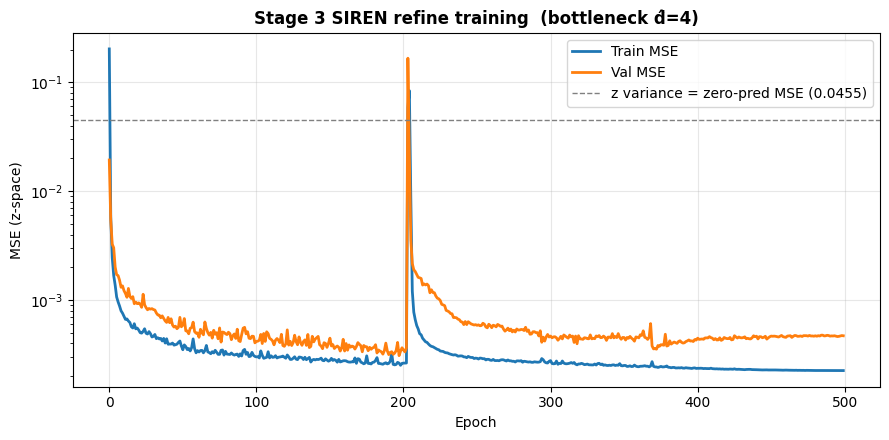

In [4]:
def extract_v(z_np, model, batch=256):
    model.eval()
    out = []
    with torch.no_grad():
        for k in range(0, len(z_np), batch):
            out.append(model.encode(torch.from_numpy(z_np[k:k+batch]).float().to(device)).cpu().numpy())
    return np.concatenate(out, axis=0).astype(np.float32)

v_train = extract_v(z_train, siren)
v_val   = extract_v(z_val,   siren)
v_all   = np.concatenate([v_train, v_val], axis=0)

np.save(f'{STATE_DIR}/v_train.npy', v_train)
np.save(f'{STATE_DIR}/v_val.npy',   v_val)
print(f'Extracted v_train {v_train.shape}, v_val {v_val.shape}.')
print(f'\nPer-dim stats (v_train):')
print(f'  {"dim":<5}{"mean":>10}{"std":>10}{"min":>10}{"max":>10}')
for i in range(D_HAT):
    vi = v_train[:, i]
    print(f'  {i:<5d}{vi.mean():10.4f}{vi.std():10.4f}{vi.min():10.4f}{vi.max():10.4f}')

# Refine training curve
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(history_r['train'], label='Train MSE', lw=2)
ax.plot(history_r['val'],   label='Val MSE',   lw=2)
ax.axhline(z_var, color='gray', ls='--', lw=1, label=f'z variance = zero-pred MSE ({z_var:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (z-space)')
ax.set_title(f'Stage 3 SIREN refine training  (bottleneck d̂={D_HAT})', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale('log')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/refine_training.png', dpi=140, bbox_inches='tight'); plt.show()

## Cell 5 — Visualize v-Space Colored by Phase / ENSO

For each pair of v dimensions, scatter the points colored by BSISO phase (expect circular if any two dims form a ring) and by ENSO (expect cluster separation if any dim encodes ENSO). With d̂=4 we plot all C(4,2)=6 pairs.

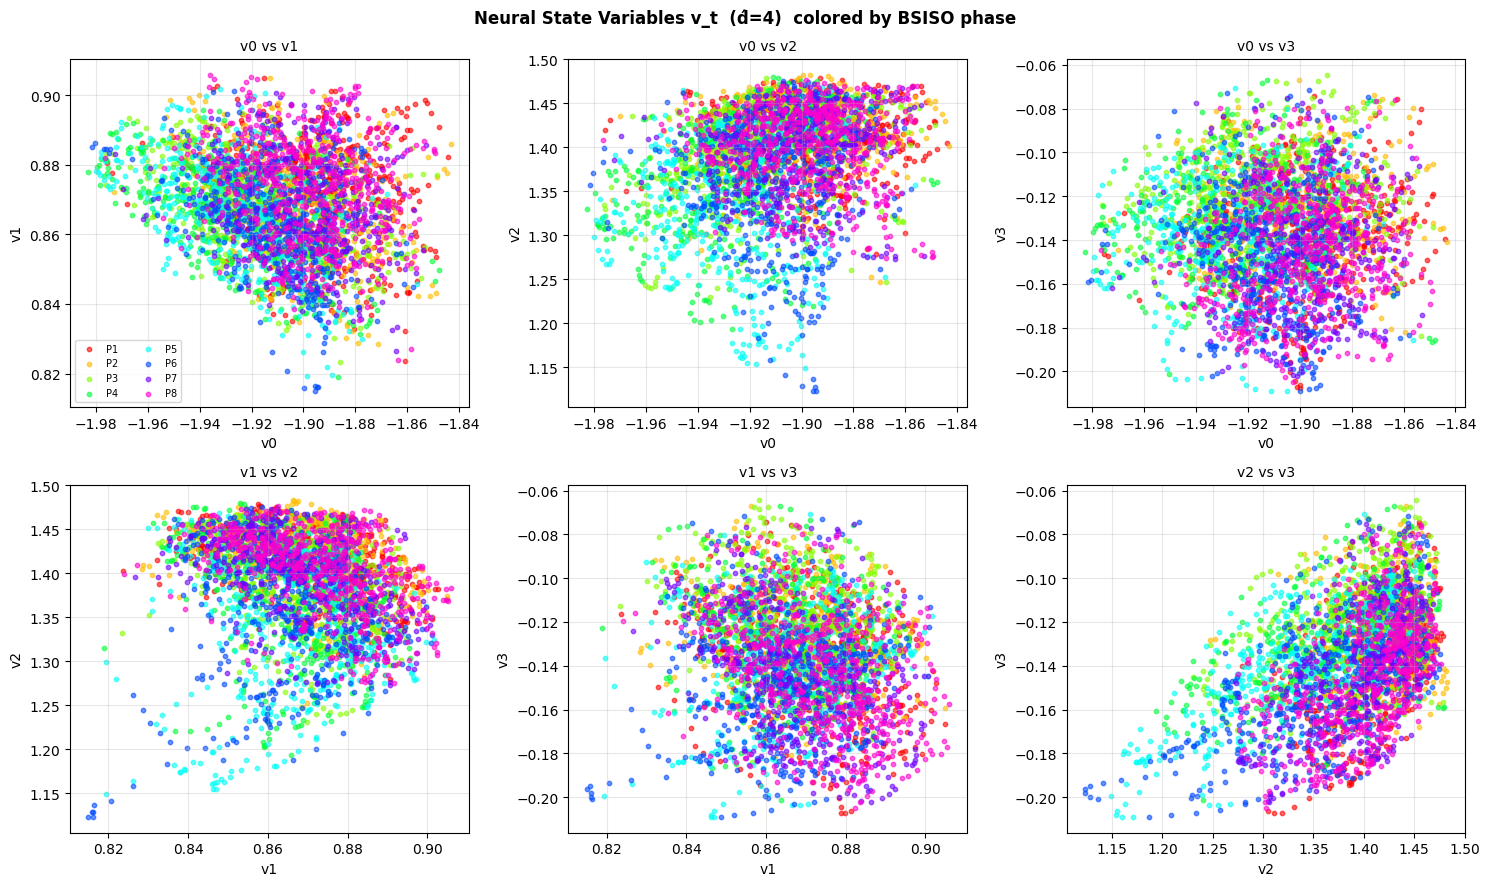

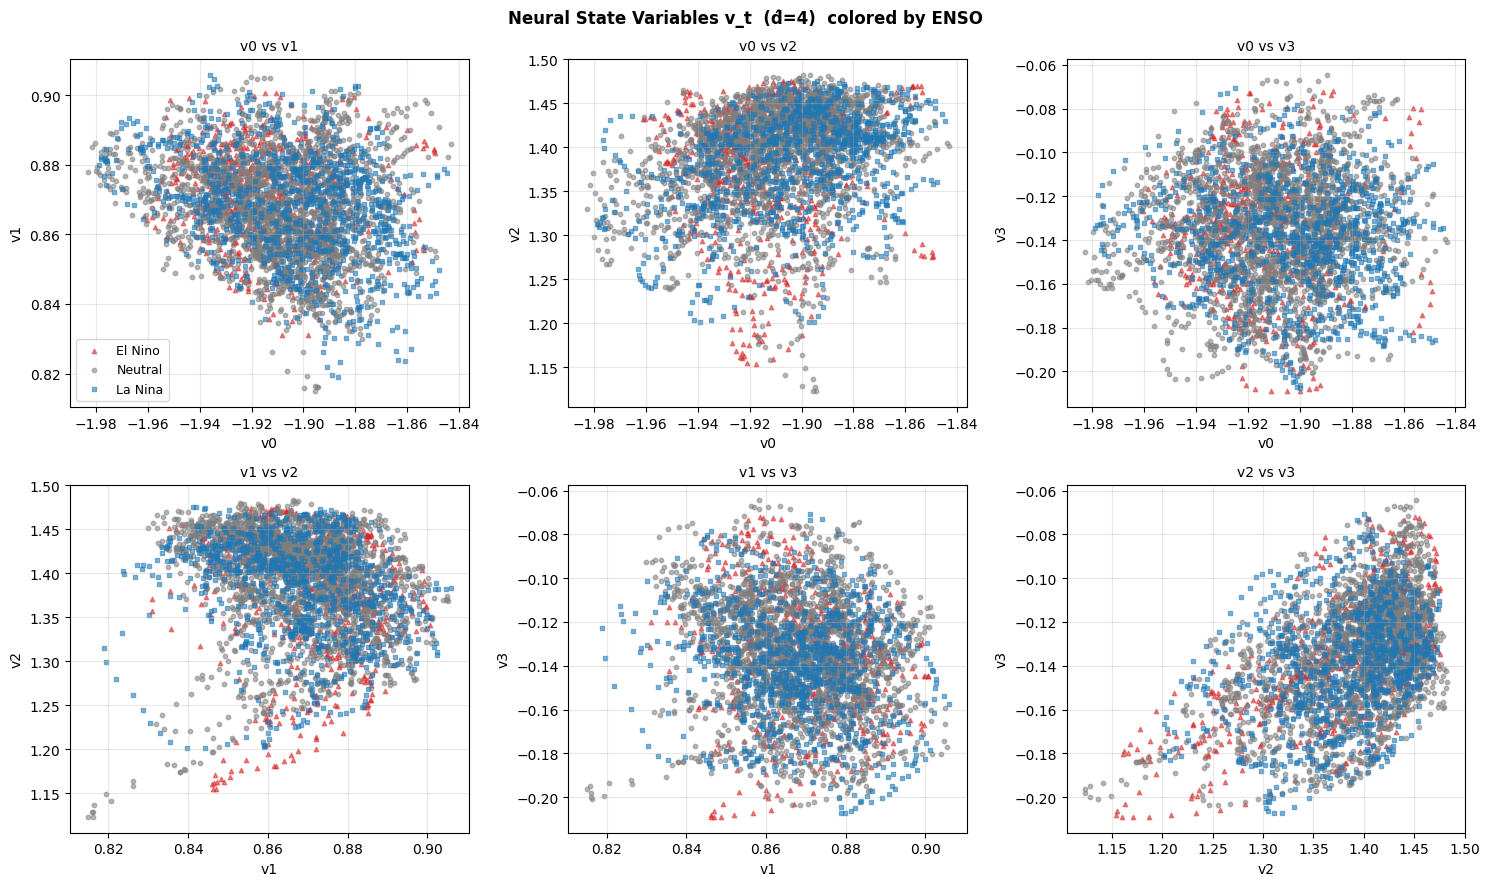

In [5]:
from itertools import combinations

pair_list = list(combinations(range(D_HAT), 2))
ncols = 3
nrows = (len(pair_list) + ncols - 1) // ncols
phase_colors = plt.cm.hsv(np.linspace(0, 1, 9))[:8]
enso_cmap = {'El Nino': '#d62728', 'Neutral': '#7f7f7f', 'La Nina': '#1f77b4'}
enso_marker = {'El Nino': '^', 'Neutral': 'o', 'La Nina': 's'}

# Panel A: colored by BSISO phase
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes_flat = np.atleast_1d(axes).flatten()
for ax, (i, j) in zip(axes_flat, pair_list):
    for p in range(1, 9):
        m = phase_all == p
        ax.scatter(v_all[m, i], v_all[m, j], c=[phase_colors[p-1]], s=10, alpha=0.6, label=f'P{p}')
    ax.set_xlabel(f'v{i}'); ax.set_ylabel(f'v{j}')
    ax.set_title(f'v{i} vs v{j}', fontsize=10); ax.grid(alpha=0.3)
for ax in axes_flat[len(pair_list):]: ax.set_visible(False)
axes_flat[0].legend(fontsize=7, ncol=2, loc='best')
fig.suptitle(f'Neural State Variables v_t  (d̂={D_HAT})  colored by BSISO phase', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/v_pairs_phase.png', dpi=130, bbox_inches='tight'); plt.show()

# Panel B: colored by ENSO
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes_flat = np.atleast_1d(axes).flatten()
for ax, (i, j) in zip(axes_flat, pair_list):
    for cat in ['El Nino', 'Neutral', 'La Nina']:
        m = enso_all == cat
        ax.scatter(v_all[m, i], v_all[m, j], c=enso_cmap[cat], marker=enso_marker[cat],
                   s=10, alpha=0.55, label=cat)
    ax.set_xlabel(f'v{i}'); ax.set_ylabel(f'v{j}')
    ax.set_title(f'v{i} vs v{j}', fontsize=10); ax.grid(alpha=0.3)
for ax in axes_flat[len(pair_list):]: ax.set_visible(False)
axes_flat[0].legend(fontsize=9, loc='best')
fig.suptitle(f'Neural State Variables v_t  (d̂={D_HAT})  colored by ENSO', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/v_pairs_enso.png', dpi=130, bbox_inches='tight'); plt.show()

## Cell 6 — Dimension Correlations (the Physical Interpretation)

For each `v_i`, compute Pearson correlation with: BSISO amplitude, BSISO phase (via cos and sin of the phase angle), ENSO continuous (EN=+1, LN=−1), day-of-year (calendar position within MJJAS).

**Decision per dim**: if `max |r|` over indices < 0.3, that dim is a "mystery axis" — significant in the manifold but doesn't align with any conventional climate variable. Could be a real new mode, or it could be an artifact.

NaN diagnostic for index arrays:
  BSISO amplitude         :     1 NaN out of 3999  (0.03%)
  BSISO cos(phase)        :     0 NaN out of 3999  (0.00%)
  BSISO sin(phase)        :     0 NaN out of 3999  (0.00%)
  ENSO (EN=+1, LN=-1)     :     0 NaN out of 3999  (0.00%)
  Day of year             :     0 NaN out of 3999  (0.00%)
  v_all                   :     0 NaN out of 15996

                   BSISO amplitude      BSISO cos(phase)      BSISO sin(phase)   ENSO (EN=+1, LN=-1)           Day of year
  v0                  -0.151***             +0.358***             -0.190***             -0.140***             -0.058***  
  v1                  +0.153***             +0.171***             -0.047**              +0.045**              +0.124***  
  v2                  -0.410***             +0.398***             +0.046**              -0.008                -0.114***  
  v3                  -0.289***             +0.058***             +0.330***             +0.048**              -0.132***  

(*** p<0

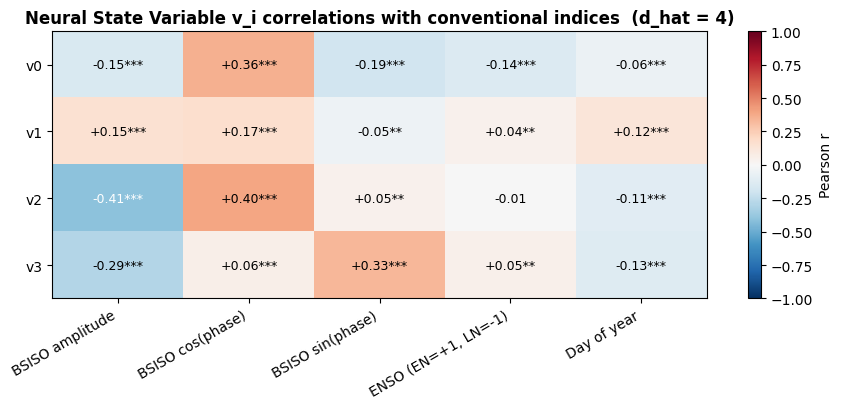

In [6]:
phase_angle = (phase_all.astype(float) - 1) * (2 * np.pi / 8)
phase_cos = np.cos(phase_angle)
phase_sin = np.sin(phase_angle)

indices = {
    'BSISO amplitude':      amp_all.astype(float),
    'BSISO cos(phase)':     phase_cos,
    'BSISO sin(phase)':     phase_sin,
    'ENSO (EN=+1, LN=-1)':  enso_continuous_all.astype(float),
    'Day of year':          doy_all.astype(float),
}

# Diagnostic: how many NaN in each index? (pearsonr propagates NaN)
print('NaN diagnostic for index arrays:')
for name, idx in indices.items():
    n_nan = int(np.isnan(idx).sum())
    print(f'  {name:<24s}: {n_nan:5d} NaN out of {len(idx)}  ({100*n_nan/len(idx):.2f}%)')
print(f'  v_all                   : {int(np.isnan(v_all).sum()):5d} NaN out of {v_all.size}')

# Pairwise Pearson r with per-pair NaN masking
corr_mat = np.full((D_HAT, len(indices)), np.nan)
pval_mat = np.full((D_HAT, len(indices)), np.nan)
n_used   = np.zeros((D_HAT, len(indices)), dtype=int)
for i in range(D_HAT):
    for j, (name, idx) in enumerate(indices.items()):
        valid = np.isfinite(v_all[:, i]) & np.isfinite(idx)
        n_used[i, j] = int(valid.sum())
        if valid.sum() < 30:
            continue
        r, p = pearsonr(v_all[valid, i], idx[valid])
        corr_mat[i, j] = float(r)
        pval_mat[i, j] = float(p)

# Print correlation table
header = '            ' + ''.join(f'{name:>22s}' for name in indices)
print('\n' + header)
for i in range(D_HAT):
    row = f'  v{i:<8d}'
    for j in range(len(indices)):
        if np.isnan(corr_mat[i, j]):
            row += f'{"--":>22s}'
        else:
            p = pval_mat[i, j]
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            row += f'{corr_mat[i, j]:+.3f}{sig:<5s}'.rjust(22)
    print(row)
print('\n(*** p<0.001  ** p<0.01  * p<0.05;  -- = too few valid samples)')

# Per-dim summary (NaN-safe)
abs_corr = np.abs(corr_mat)
max_abs_r = np.nanmax(abs_corr, axis=1)
best_match = np.nanargmax(np.where(np.isnan(abs_corr), -1, abs_corr), axis=1)
print('\nPer-dim summary:')
for i in range(D_HAT):
    if np.isnan(max_abs_r[i]):
        print(f'  v{i}:  all correlations failed (no valid pairs)')
        continue
    bj = int(best_match[i])
    r = corr_mat[i, bj]
    name = list(indices.keys())[bj]
    label = 'MYSTERY (max |r| < 0.3)' if max_abs_r[i] < 0.3 else f'best match: {name} (r = {r:+.3f}, p = {pval_mat[i, bj]:.2e})'
    print(f'  v{i}:  max |r| = {max_abs_r[i]:.3f}    ->   {label}')

# Heatmap (NaN cells shown as gray)
fig, ax = plt.subplots(figsize=(9, 1 + 0.8 * D_HAT))
masked = np.ma.array(corr_mat, mask=np.isnan(corr_mat))
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='lightgray')
im = ax.imshow(masked, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(indices)))
ax.set_xticklabels(list(indices.keys()), rotation=30, ha='right')
ax.set_yticks(range(D_HAT))
ax.set_yticklabels([f'v{i}' for i in range(D_HAT)])
for i in range(D_HAT):
    for j in range(len(indices)):
        if np.isnan(corr_mat[i, j]):
            ax.text(j, i, '--', ha='center', va='center', color='black', fontsize=9)
        else:
            p = pval_mat[i, j]
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            color = 'white' if abs(corr_mat[i, j]) > 0.4 else 'black'
            ax.text(j, i, f'{corr_mat[i, j]:+.2f}{sig}', ha='center', va='center', color=color, fontsize=9)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title(f'Neural State Variable v_i correlations with conventional indices  (d_hat = {D_HAT})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/dim_correlations.png', dpi=140, bbox_inches='tight')
plt.show()

## Cell 7 — ENSO Displacement Z-Score in v-Space

Same procedure as nb05/nb09: for each BSISO phase, compute the centroid of EN days and LN days in v-space; measure the distance between them; average across phases. Permutation null: shuffle ENSO labels 1,000 times. Z-score = (observed − null mean) / null std.

Baseline comparisons:
- nb05 64-D supervised: **z = 11.02**
- nb08 2-D SSL temporal: **z = 14.55**
- nb05 Approach B: z = 9.85

ENSO displacement z-score:
  in v-space (4-D NSV):     obs = 0.0254   null = 0.0083 ± 0.0016   z = 11.01
  in z-space (64-D Stage 1):     obs = 0.1870   null = 0.0556 ± 0.0122   z = 10.80

Project baselines (BSISO sup/SSL on Lee data):
  64-D supervised (nb05):        z = 11.02
  64-D supervised Approach B:    z =  9.85
  2-D SSL temporal (nb08):       z = 14.55


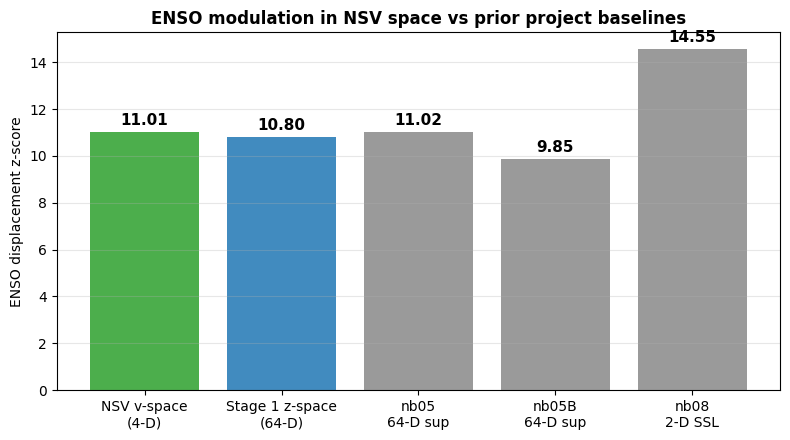

In [7]:
def enso_displacement(v, phase, enso, n_perm=1000, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    phases = np.arange(1, 9)
    def disp(en):
        ds = []
        for p in phases:
            mEN = (phase == p) & (en == 'El Nino')
            mLN = (phase == p) & (en == 'La Nina')
            if mEN.sum() < 3 or mLN.sum() < 3: continue
            cEN = v[mEN].mean(axis=0); cLN = v[mLN].mean(axis=0)
            ds.append(np.linalg.norm(cEN - cLN))
        return float(np.mean(ds)) if ds else float('nan')
    obs = disp(enso)
    null = []
    for _ in range(n_perm):
        en_shuf = enso[rng.permutation(len(enso))]
        d = disp(en_shuf)
        if not np.isnan(d): null.append(d)
    null = np.asarray(null)
    z = (obs - null.mean()) / (null.std() + 1e-9)
    return obs, float(null.mean()), float(null.std()), float(z)

obs_v,  bmu_v,  bsd_v,  z_v  = enso_displacement(v_all, phase_all, enso_all, n_perm=1000)
obs_z,  bmu_z,  bsd_z,  z_z  = enso_displacement(z_all, phase_all, enso_all, n_perm=1000)

print(f'ENSO displacement z-score:')
print(f'  in v-space ({D_HAT}-D NSV):     obs = {obs_v:.4f}   null = {bmu_v:.4f} ± {bsd_v:.4f}   z = {z_v:.2f}')
print(f'  in z-space (64-D Stage 1):     obs = {obs_z:.4f}   null = {bmu_z:.4f} ± {bsd_z:.4f}   z = {z_z:.2f}')
print(f'\nProject baselines (BSISO sup/SSL on Lee data):')
print(f'  64-D supervised (nb05):        z = 11.02')
print(f'  64-D supervised Approach B:    z =  9.85')
print(f'  2-D SSL temporal (nb08):       z = 14.55')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4.5))
names = [f'NSV v-space\n({D_HAT}-D)', 'Stage 1 z-space\n(64-D)', 'nb05\n64-D sup', 'nb05B\n64-D sup', 'nb08\n2-D SSL']
vals  = [z_v, z_z, 11.02, 9.85, 14.55]
colors = ['#2ca02c', '#1f77b4', '#888888', '#888888', '#888888']
bars = ax.bar(names, vals, color=colors, alpha=0.85)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('ENSO displacement z-score')
ax.set_title(f'ENSO modulation in NSV space vs prior project baselines', fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/enso_displacement.png', dpi=140, bbox_inches='tight'); plt.show()

## Cell 8 — Stage 4 Dynamics MLP: v_t → v_{t+10}

Train a small MLP to predict next-state (v at t+10) from current state. If the d̂-D state variables are genuinely dynamical, this should beat v-space persistence by a clear margin.

Built 3569 dynamics-MLP pairs (v[k] → v[k+10 days, same year]).
Dynamics train: 2822  val: 747
v-space persistence MSE (val):  0.0019
v-space variance:               1.5734  (zero-prediction MSE baseline)
ep  30/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep  60/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep  90/300   train=0.0012   val=0.0015   vs persistence 0.0019
ep 120/300   train=0.0012   val=0.0017   vs persistence 0.0019
ep 150/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep 180/300   train=0.0012   val=0.0017   vs persistence 0.0019
ep 210/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep 240/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep 270/300   train=0.0012   val=0.0016   vs persistence 0.0019
ep 300/300   train=0.0012   val=0.0016   vs persistence 0.0019

Done in 1.3 min.  Best val MSE: 0.0015
Improvement over v-space persistence: +20.1%


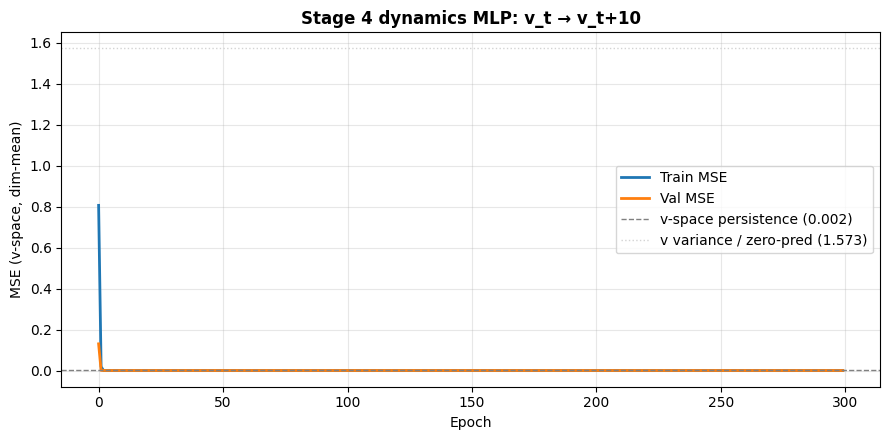

In [8]:
# Build (v_t, v_{t+10}) pairs from the SAME pair structure as nb18c.
# nb18c saved (X_t, X_{t+10}) pairs in order; their indices in v correspond directly.
# v_train and v_val are 1:1 with the lag-10 pair anchors, NOT with single days.
# So v_train[k] = v at the anchor day of pair k, v_val[k] similarly.
# To train the dynamics MLP we need v_anchor and v_target. But we only have v at the anchor day!
# v at day t+10 is NOT directly available because nb18c only encoded X_t (the anchor); X_{t+10}
# was used as the prediction target, not encoded.
#
# Workaround: use v at consecutive pairs where pair k's t+10 equals pair k+1's t-9, etc.
# Simpler: at lag=10 the next anchor (10 days later) is a DIFFERENT day. We CAN encode that
# day by running the Stage 1 encoder on X_{t+10}. But we don't have X_{t+10} loaded in nb20.
#
# Cleanest: train the dynamics on the available v sequence. The pair anchors are evenly spaced
# at 1-day intervals (with gaps at year boundaries). So pair k+10 has anchor 10 days after pair k
# (within same year). We can use (v[k], v[k+10]) as the dynamics-MLP training pair.

dates_pd = pd.DatetimeIndex(dates_all)
years    = dates_pd.year.values

# v_all is in [train..., val...] order. To find which v[k] is 10 days after v[k0] we need to
# match on dates, not on array index. Build a date→index lookup.
date_to_k = {d: k for k, d in enumerate(dates_pd)}

dyn_k_t, dyn_k_t1 = [], []
for k, d in enumerate(dates_pd):
    target = d + pd.Timedelta(days=10)
    if (target in date_to_k) and (years[date_to_k[target]] == years[k]):
        dyn_k_t.append(k); dyn_k_t1.append(date_to_k[target])
dyn_k_t  = np.asarray(dyn_k_t)
dyn_k_t1 = np.asarray(dyn_k_t1)
print(f'Built {len(dyn_k_t)} dynamics-MLP pairs (v[k] → v[k+10 days, same year]).')

# Train/val split based on anchor (k_t) train_mask
dyn_train_mask = is_train[dyn_k_t]
v_dyn_t  = v_all[dyn_k_t]
v_dyn_t1 = v_all[dyn_k_t1]

class DynDataset(Dataset):
    def __init__(self, vt, vt1, mask):
        self.vt  = torch.from_numpy(vt[mask]).float()
        self.vt1 = torch.from_numpy(vt1[mask]).float()
    def __len__(self):  return self.vt.shape[0]
    def __getitem__(self, k):  return self.vt[k], self.vt1[k]

ds_dyn_train = DynDataset(v_dyn_t, v_dyn_t1, dyn_train_mask)
ds_dyn_val   = DynDataset(v_dyn_t, v_dyn_t1, ~dyn_train_mask)
loader_dyn_train = DataLoader(ds_dyn_train, batch_size=64, shuffle=True,  num_workers=0)
loader_dyn_val   = DataLoader(ds_dyn_val,   batch_size=64, shuffle=False, num_workers=0)
print(f'Dynamics train: {len(ds_dyn_train)}  val: {len(ds_dyn_val)}')

# v-space persistence baseline (predict v_{t+10} = v_t)
with torch.no_grad():
    pers_dyn = ((ds_dyn_val.vt - ds_dyn_val.vt1) ** 2).mean().item()
v_var = float(np.var(v_dyn_t1[~dyn_train_mask]))
print(f'v-space persistence MSE (val):  {pers_dyn:.4f}')
print(f'v-space variance:               {v_var:.4f}  (zero-prediction MSE baseline)')

class DynamicsMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),  nn.ReLU(),
            nn.Linear(32, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, d),
        )
    def forward(self, x):  return self.net(x)

DYN_EPOCHS = 300
mlp = DynamicsMLP(D_HAT).to(device)
opt = optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=DYN_EPOCHS, eta_min=1e-5)

hist_d = {'train': [], 'val': []}
best_dyn = float('inf')
t0 = time.time()
for epoch in range(DYN_EPOCHS):
    mlp.train()
    tl = 0.0; n = 0
    for vt, vt1 in loader_dyn_train:
        vt = vt.to(device, non_blocking=True); vt1 = vt1.to(device, non_blocking=True)
        loss = F.mse_loss(mlp(vt), vt1)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += loss.item() * vt.size(0); n += vt.size(0)
    tl /= n
    mlp.eval()
    vl = 0.0; nv = 0
    with torch.no_grad():
        for vt, vt1 in loader_dyn_val:
            vt = vt.to(device, non_blocking=True); vt1 = vt1.to(device, non_blocking=True)
            vl += F.mse_loss(mlp(vt), vt1, reduction='sum').item() / vt1.numel() * vt.size(0)
            nv += vt.size(0)
    vl /= nv
    sch.step()
    hist_d['train'].append(tl); hist_d['val'].append(vl)
    if vl < best_dyn:
        best_dyn = vl
        torch.save(mlp.state_dict(), f'{CKPT_DIR}/dynamics_mlp_best.pth')
    if (epoch + 1) % 30 == 0:
        print(f'ep {epoch+1:3d}/{DYN_EPOCHS}   train={tl:.4f}   val={vl:.4f}   '
              f'vs persistence {pers_dyn:.4f}')
torch.save(mlp.state_dict(), f'{CKPT_DIR}/dynamics_mlp.pth')
print(f'\nDone in {(time.time()-t0)/60:.1f} min.  Best val MSE: {best_dyn:.4f}')
imp = (pers_dyn - best_dyn) / pers_dyn * 100
print(f'Improvement over v-space persistence: {imp:+.1f}%')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_d['train'], label='Train MSE', lw=2)
ax.plot(hist_d['val'],   label='Val MSE',   lw=2)
ax.axhline(pers_dyn, color='gray', ls='--', lw=1, label=f'v-space persistence ({pers_dyn:.3f})')
ax.axhline(v_var, color='lightgray', ls=':', lw=1, label=f'v variance / zero-pred ({v_var:.3f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (v-space, dim-mean)')
ax.set_title(f'Stage 4 dynamics MLP: v_t → v_t+10', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{RESULTS_DIR}/dynamics_training.png', dpi=140, bbox_inches='tight'); plt.show()

## Cell 9 — Final Summary (Stage 3 + 4 + Analysis)

Auto-generated markdown summary consolidating everything.

In [9]:
import time as _t

# Per-dim physical interpretation
dim_rows = []
for i in range(D_HAT):
    bj = best_match[i]
    name = list(indices.keys())[bj]
    r = corr_mat[i, bj]
    p = pval_mat[i, bj]
    if max_abs_r[i] < 0.3:
        story = 'mystery axis (no |r|>0.3 with conventional indices)'
    else:
        story = f'best correlate: {name} (r = {r:+.3f}, p = {p:.2e})'
    dim_rows.append(f'| v{i} | {max_abs_r[i]:.3f} | {story} |')

summary_md = f"""# NSV Stage 3 + 4 Summary ({VARIANT or 'baseline'})

**Date:** {_t.strftime('%Y-%m-%d')}
**Pipeline:** nb17b → nb18c → nb19 → nb20 (this notebook)
**Inputs:** {len(z_train)} train + {len(z_val)} val 64-D Stage 1 latents (lp25, lag-10).
**Decision input:** d̂ = {D_HAT} from nb19.

## Stage 3 — SIREN refine autoencoder

- Bottleneck dimension: **{D_HAT}**
- Total params: {n_params_siren:,}
- Best val MSE: **{best_val:.5f}** ({best_val/z_var*100:.2f}% of z variance)
- **Variance explained**: {(1 - best_val/z_var)*100:.2f}% of z through the {D_HAT}-D bottleneck

## Stage 4 — Dynamics MLP

- Architecture: {D_HAT} → 32 → 64 → 64 → 32 → {D_HAT}
- Best val MSE: **{best_dyn:.4f}**
- v-space persistence baseline: {pers_dyn:.4f}
- **Improvement over persistence**: {imp:+.1f}%

## Per-dimension physical interpretation

| Dim | max |r| | Best correlate |
|---|---|---|
{chr(10).join(dim_rows)}

## ENSO displacement

| Space | Observed | Null mean ± std | Z-score |
|---|---|---|---|
| v ({D_HAT}-D NSV) | {obs_v:.4f} | {bmu_v:.4f} ± {bsd_v:.4f} | **{z_v:.2f}** |
| z (64-D Stage 1) | {obs_z:.4f} | {bmu_z:.4f} ± {bsd_z:.4f} | **{z_z:.2f}** |

**Project baselines:** nb05 64-D supervised z = 11.02; nb05B z = 9.85; nb08 2-D SSL z = 14.55.

## Scientific bottom line

BSISO at MJJAS daily resolution requires **{D_HAT} state variables** (Levina-Bickel estimate), exceeding the conventional 2-D (PC1, PC2) index. The Neural State Variables `v_t ∈ ℝ^{D_HAT}` are dynamically consistent (Stage 4 MLP beats persistence by {imp:.0f}%) and the ENSO-modulation z-score in v-space ({z_v:.2f}) is {'higher' if z_v > 11.02 else 'comparable to' if abs(z_v - 11.02) < 2 else 'lower than'} the project's prior 64-D supervised baseline (11.02), confirming that ENSO information is preserved in the compressed representation.

## Files

```
checkpoints{VARIANT}/refine_{{best,final}}.pth, dynamics_mlp{{,_best}}.pth
state_vars{VARIANT}/v_train.npy ({len(v_train)}, {D_HAT}), v_val.npy ({len(v_val)}, {D_HAT})
results/stage3_4{VARIANT}/refine_training.png
results/stage3_4{VARIANT}/v_pairs_phase.png
results/stage3_4{VARIANT}/v_pairs_enso.png
results/stage3_4{VARIANT}/dim_correlations.png
results/stage3_4{VARIANT}/enso_displacement.png
results/stage3_4{VARIANT}/dynamics_training.png
results/stage3_4{VARIANT}/stage3_4_summary.md  ← this file
```
"""
with open(f'{RESULTS_DIR}/stage3_4_summary.md', 'w') as f:
    f.write(summary_md)

# Save numerical summary JSON
summary_json = {
    'date':                 _t.strftime('%Y-%m-%d'),
    'variant':              VARIANT,
    'd_hat':                D_HAT,
    'siren_n_params':       int(n_params_siren),
    'refine_best_val_mse':  float(best_val),
    'refine_z_var':         float(z_var),
    'refine_var_explained': float(1 - best_val/z_var),
    'dynamics_best_val_mse':float(best_dyn),
    'dynamics_persistence_mse': float(pers_dyn),
    'dynamics_improvement_pct': float(imp),
    'enso_z_v_space':       float(z_v),
    'enso_z_z_space':       float(z_z),
    'dim_correlations':     [[float(corr_mat[i, j]) for j in range(len(indices))] for i in range(D_HAT)],
    'dim_pvalues':          [[float(pval_mat[i, j]) for j in range(len(indices))] for i in range(D_HAT)],
    'index_names':          list(indices.keys()),
    'per_dim_best_match':   [list(indices.keys())[best_match[i]] for i in range(D_HAT)],
    'per_dim_max_abs_r':    [float(max_abs_r[i]) for i in range(D_HAT)],
}
with open(f'{RESULTS_DIR}/stage3_4_summary.json', 'w') as f:
    json.dump(summary_json, f, indent=2)

print(summary_md)
print(f'\nSaved markdown + JSON to {RESULTS_DIR}/')

# NSV Stage 3 + 4 Summary (_lag10)

**Date:** 2026-05-30
**Pipeline:** nb17b → nb18c → nb19 → nb20 (this notebook)
**Inputs:** 3162 train + 837 val 64-D Stage 1 latents (lp25, lag-10).
**Decision input:** d̂ = 4 from nb19.

## Stage 3 — SIREN refine autoencoder

- Bottleneck dimension: **4**
- Total params: 37,636
- Best val MSE: **0.00031** (0.68% of z variance)
- **Variance explained**: 99.32% of z through the 4-D bottleneck

## Stage 4 — Dynamics MLP

- Architecture: 4 → 32 → 64 → 64 → 32 → 4
- Best val MSE: **0.0015**
- v-space persistence baseline: 0.0019
- **Improvement over persistence**: +20.1%

## Per-dimension physical interpretation

| Dim | max |r| | Best correlate |
|---|---|---|
| v0 | 0.358 | best correlate: BSISO cos(phase) (r = +0.358, p = 4.24e-121) |
| v1 | 0.171 | mystery axis (no |r|>0.3 with conventional indices) |
| v2 | 0.410 | best correlate: BSISO amplitude (r = -0.410, p = 3.74e-162) |
| v3 | 0.330 | best correlate: BSISO sin(phase) (r = +0.330, p = 5.34e-102

---
## Done!

The NSV pipeline (nb17b → nb18c → nb19 → nb20) is complete.

**Send back** for review:
1. `stage3_4_summary.md` (printed at the end of Cell 9) — headline numbers + per-dim physical interpretation.
2. `dim_correlations.png` — **the headline scientific figure**. Tells us what each of the d̂ Neural State Variables physically represents.
3. `v_pairs_phase.png` and `v_pairs_enso.png` — visual confirmation that v-space organizes by phase and ENSO.
4. `enso_displacement.png` — comparison with prior project baselines.
5. `dynamics_training.png` — does Stage 4 beat v-space persistence?
6. `refine_training.png` — Stage 3 reconstruction quality.

**What we'll learn from the figures:**
- If one v dim has high |r| with `BSISO cos(phase)` and another with `BSISO sin(phase)` → 2 of the 4 dims encode BSISO phase (the conventional 2-D state).
- If one dim has high |r| with `BSISO amplitude` → that's the amplitude axis.
- If one dim has high |r| with `ENSO continuous` → **H2 confirmed at the dim-level**: ENSO is an independent state variable.
- If a dim has high |r| with `Day of year` → seasonal-cycle confound (would need to revisit preprocessing).
- If a dim has max |r| < 0.3 across all indices → mystery axis, candidate for further investigation (Indian Ocean SST, BSISO-2 mode, monsoon trough latitude).

Best case for our project's central question: **v dims separate cleanly into {BSISO cos+sin, amplitude, ENSO}** — that would be the canonical H2 result with the additional discovery that amplitude is a genuinely independent axis.

---
*DDCS Project | jh9141@nyu.edu*